# 15_Naive Bayes

# Naive Bayes

앞 강의에서는 k-NN을 이용하여 Classification을 수행하였다.

k-NN은 새로운 Data와 가까운 Training Data를 찾아 Class를 결정하였다.

이번에는 다른 방법을 사용한다.

> 주어진 Feature가 각 Class에서 나타날 Probability를 이용하여 Class를 결정한다.

이 방법을 Naive Bayes라고 한다.

## Classification using Probability

새로운 Data $X$가 주어졌을 때 우리가 알고 싶은 것은

$$
P(C_k|X)
$$

이다.

즉,

> Data $X$가 주어졌을 때 Class $C_k$일 Probability

를 계산하고 가장 큰 Probability를 가지는 Class를 선택한다.

$$
\hat{y}
=
\arg\max_k P(C_k|X)
$$

## Bayes Theorem

Bayes Theorem은 다음과 같다.

$$
P(C|X)
=
\frac{P(X|C)P(C)}
{P(X)}
$$

Classification에서는 여러 Class를 비교하므로 공통으로 나타나는 $P(X)$는 생략할 수 있다.

따라서

$$
P(C|X)
\propto
P(X|C)P(C)
$$

를 비교한다.

## Bayes Theorem - A Simple Example

다음과 같이 양면에 색이 칠해진 3개의 Cards가 있다.

- Card 1: Red - Red
- Card 2: Blue - Red
- Card 3: Blue - Blue

3개의 Cards 중 하나를 Random하게 선택하여 바닥에 떨어뜨렸다.

각 Card의 어느 면이 위를 향할지는 Random하다고 가정한다.

위를 향한 면을 확인했더니 Red였다.

> 이 Card의 뒷면도 Red일 Probability는 얼마인가?

## Using Bayes Theorem

다음과 같이 정의하자.

$C$:

> 선택한 Card가 Red-Red Card이다.

$X$:

> 관찰한 면이 Red이다.

우리가 알고 싶은 것은

$$
P(C|X)
$$

이다.

Bayes Theorem에 따르면

$$
P(C|X)
=
\frac{P(X|C)P(C)}{P(X)}
$$

이다.

## Prior Probability

3개의 Cards 중 하나를 Random하게 선택하므로

$$
P(C)=\frac{1}{3}
$$

이다.

이것이 Prior Probability이다.

Red-Red Card가 선택되었다면 어느 면이 위를 향하더라도 Red이다.

따라서

$$
P(X|C)=1
$$

이다.

## Probability of Observing Red

Red 면을 관찰할 Probability는

$$
P(X)
=
P(X|RR)P(RR)
+
P(X|RB)P(RB)
+
P(X|BB)P(BB)
$$

이다.

각각

$$
P(X|RR)=1
$$

$$
P(X|RB)=\frac{1}{2}
$$

$$
P(X|BB)=0
$$

이므로

$$
P(X)
=
1\times\frac{1}{3}
+
\frac{1}{2}\times\frac{1}{3}
+
0\times\frac{1}{3}
=
\frac{1}{2}
$$

## Posterior Probability

따라서

$$
P(C|X)
=
\frac{
1\times\frac{1}{3}
}{
\frac{1}{2}
}
=
\frac{2}{3}
$$

이다.

즉,

> 보이는 면이 Red라면 뒷면도 Red일 Probability는 $\frac{2}{3}$이다.

## Connection to Classification

이 예제에서 우리는 Observation $X$를 이용하여 어떤 Card $C$가 선택되었는지를 추론하였다.

Bayes Classification도 같은 생각을 사용한다.

$$
P(C|X)
=
\frac{P(X|C)P(C)}{P(X)}
$$

여러 Class를 비교할 때 $P(X)$는 모든 Class에서 동일하다.

따라서

$$
P(C|X)
\propto
P(X|C)P(C)
$$

만 비교하면 된다.

즉,

> Observation $X$가 주어졌을 때 어떤 Class가 가장 가능성이 높은가?

를 계산하는 것이 Bayes Classification의 기본 아이디어이다.

## Why "Naive"?

Input에 여러 Features가 있다고 하자.

$$
X=(x_1,x_2,\ldots,x_p)
$$

Naive Bayes는 Class가 주어졌을 때 각 Feature가 서로 Independent하다고 가정한다.

$$
P(X|C)
=
P(x_1|C)
P(x_2|C)
\cdots
P(x_p|C)
$$

이 가정은 실제 Data에서는 완전히 성립하지 않을 수 있다.

그러나 계산이 단순하고 많은 Classification Problem에서 좋은 성능을 보일 수 있다.

## Gaussian Naive Bayes

Iris Dataset의 Features는 Numerical Values이다.

Numerical Feature에 대해서는 Gaussian Naive Bayes를 사용할 수 있다.

각 Class에서 Feature 값이 Gaussian Distribution을 따른다고 가정한다.

각 Feature에 대해 Class별로 다음 값을 학습한다.

- Mean
- Variance

그리고 새로운 Data가 각 Class에서 나타날 Probability를 계산한다.

In [3]:
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Iris Dataset
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = iris.target

display(X.head())

print("Classes:", iris.target_names)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Classes: ['setosa' 'versicolor' 'virginica']


## Train and Test Data

k-NN과 동일하게 Train Data와 Test Data를 나누어 Model을 평가한다.

이번에는 Iris의 4개 Features를 모두 사용한다.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Data:", X_train.shape)
print("Test Data:", X_test.shape)

Train Data: (120, 4)
Test Data: (30, 4)


## Gaussian Naive Bayes Model

Scikit-learn에서는 `GaussianNB`를 이용하여 Gaussian Naive Bayes를 사용할 수 있다.

Model은 Train Data에서 각 Class별 Feature Distribution을 학습한다.

In [4]:
from sklearn.naive_bayes import GaussianNB

# Model 생성
model = GaussianNB()

# Training
model.fit(
    X_train,
    y_train
)

# Prediction
y_pred = model.predict(
    X_test
)

Gaussian Naive Bayes의 Learning = 각 Class별 Feature의 Mean과 Variance + Class Prior를 Training Data에서 구하는 것

Setosa
    Sepal Length → Mean, Variance
    Sepal Width  → Mean, Variance
    Petal Length → Mean, Variance
    Petal Width  → Mean, Variance

Versicolor
    Sepal Length → Mean, Variance
    ...
    
Virginica
    Sepal Length → Mean, Variance
    ...


Logistic Regression의 fit()이 Weight와 Bias를 찾는 과정이었다면, Gaussian Naive Bayes의 fit()은 Class별 Gaussian Distribution의 Parameter를 찾는 과정

In [5]:
# 각 Class의 Prior Probability
print(model.class_prior_)

# 각 Class에서 각 Feature의 Mean
print(model.theta_)

# 각 Class에서 각 Feature의 Variance
print(model.var_)

[0.33333333 0.34166667 0.325     ]
[[4.99       3.4525     1.45       0.245     ]
 [5.9195122  2.77073171 4.24146341 1.32195122]
 [6.53333333 2.96666667 5.52051282 2.        ]]
[[0.1239     0.15249375 0.033      0.010975  ]
 [0.28693635 0.10011898 0.22584176 0.04122546]
 [0.4165812  0.0991453  0.28573307 0.08205129]]


## What Does Gaussian Naive Bayes Learn?

`model.fit(X_train, y_train)`을 실행하면 Gaussian Naive Bayes는 Training Data로부터 다음 값을 Learning한다.

### Prior Probability

각 Class가 Training Data에서 나타나는 비율을 계산한다.

예를 들어,

$P(\text{Setosa}) = 0.333$

$P(\text{Versicolor}) = 0.342$

$P(\text{Virginica}) = 0.325$

이다.

### Mean

각 Class에서 각 Feature의 Mean을 계산한다.

예를 들어 Setosa의 경우,

- Sepal Length: 4.990
- Sepal Width: 3.453
- Petal Length: 1.450
- Petal Width: 0.245

이다.

### Variance

각 Class에서 각 Feature의 Variance도 계산한다.

따라서 Gaussian Naive Bayes의 Learning은 다음과 같이 정리할 수 있다.

> 각 Class의 Prior Probability와 각 Class에서 각 Feature의 Mean과 Variance를 Training Data로부터 구한다.

새로운 Sample $X$가 주어지면 학습된 Mean과 Variance를 이용하여 각 Feature의 Probability를 계산하고,

$P(X|C)P(C)$

를 각 Class에 대해 비교한다.

가장 큰 값을 가지는 Class를 최종 Prediction으로 선택한다.

Training Data → Class별 분리 → Feature별 Mean/Variance 계산 → Normal Distribution 추정

## Evaluate the Model

Classification Result는 Accuracy를 이용하여 평가한다.

In [6]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 1.0


## Classification Probability

Naive Bayes는 각 Sample이 각 Class에 속할 Probability를 계산한다.

`predict_proba()`를 이용하면 이 값을 확인할 수 있다.

In [7]:
# Class Probability
prob = model.predict_proba(
    X_test
)

result = pd.DataFrame(
    prob,
    columns=iris.target_names
)

result["Actual"] = [
    iris.target_names[i]
    for i in y_test
]

result["Prediction"] = [
    iris.target_names[i]
    for i in y_pred
]

display(result.head(10))

,setosa,versicolor,virginica,Actual,Prediction
0,5.973274e-90,9.956358e-01,4.364233e-03,versicolor,versicolor
1,1.000000e+00,4.961581e-14,6.549224e-21,setosa,setosa
2,7.318903e-290,4.929476e-12,1.000000e+00,virginica,virginica
3,2.818425e-94,9.775936e-01,2.240644e-02,versicolor,versicolor
4,1.138778e-105,8.700226e-01,1.299774e-01,versicolor,versicolor
5,1.000000e+00,1.731802e-13,3.661702e-21,setosa,setosa
6,5.904372e-53,9.999556e-01,4.435500e-05,versicolor,versicolor
7,5.987351e-177,1.182199e-06,9.999988e-01,virginica,virginica
8,4.017525e-96,9.921583e-01,7.841724e-03,versicolor,versicolor
9,3.150718e-59,9.999390e-01,6.101719e-05,versicolor,versicolor


## Confusion Matrix

Accuracy만으로는 어떤 Class를 어떤 Class로 잘못 분류했는지 알 수 없다.

Confusion Matrix를 이용하여 Classification Result를 자세히 확인한다.

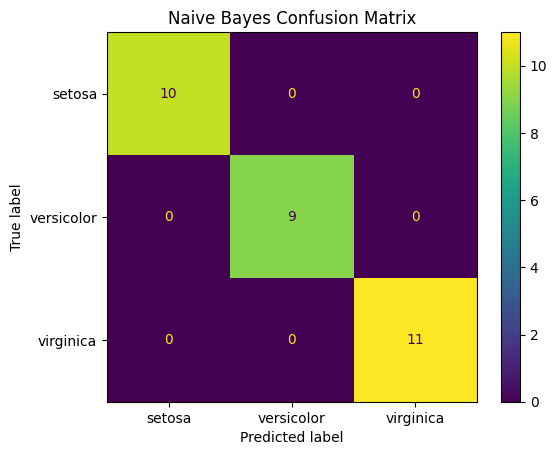

In [8]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
).plot()

plt.title("Naive Bayes Confusion Matrix")
plt.show()

## Compare with k-NN

같은 Train Data와 Test Data를 사용하여 k-NN과 Naive Bayes를 비교해 보자.

두 Methods는 Classification을 수행하지만 판단 방식은 전혀 다르다.

k-NN:

> 가까운 Training Data를 이용한다.

Naive Bayes:

> 각 Class에서 Feature가 나타날 Probability를 이용한다.

In [9]:
from sklearn.neighbors import KNeighborsClassifier

# k-NN
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

knn_pred = knn.predict(
    X_test
)

# Accuracy 비교
knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

nb_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("k-NN Accuracy:", knn_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)

k-NN Accuracy: 1.0
Naive Bayes Accuracy: 1.0


## k-NN vs Naive Bayes

k-NN과 Naive Bayes는 서로 다른 방법으로 Classification한다.

k-NN:

- Distance 기반
- 가까운 Neighbor를 이용
- Training Data 자체를 Prediction에 사용
- Feature Scale의 영향을 받음

Naive Bayes:

- Probability 기반
- Class별 Feature Distribution을 이용
- Independence Assumption 사용
- Prediction이 매우 빠름

어떤 Method가 항상 더 좋은 것은 아니다.

Data의 특성과 Problem에 따라 성능이 달라질 수 있다.

## Practice

Iris Dataset의 처음 두 Features만 사용하여 Gaussian Naive Bayes를 수행한다.

다음 Features를 사용한다.

- Sepal Length
- Sepal Width

다음 결과를 확인한다.

- Test Accuracy
- Confusion Matrix
- 첫 번째 Test Sample의 Class Probability

그리고 같은 두 Features를 사용한 $k=5$ k-NN의 Accuracy와 비교한다.

Naive Bayes Accuracy: 0.78


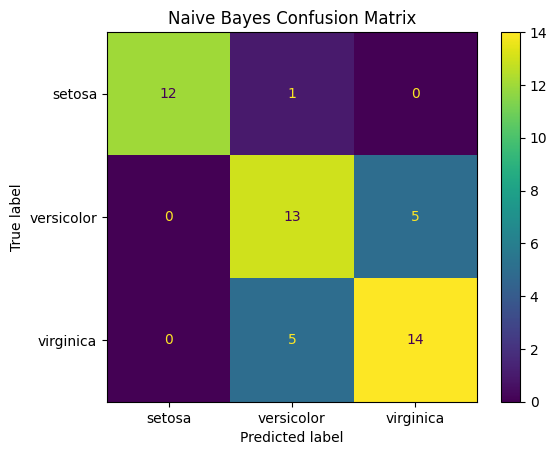

First Test Sample
Actual Class: setosa
Predicted Class: setosa
setosa: 0.950
versicolor: 0.040
virginica: 0.010

Naive Bayes Accuracy: 0.780
k-NN Accuracy: 0.680


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.utils import shuffle
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Iris Dataset
iris = load_iris()

# 처음 두 Features만 사용
# Sepal Length, Sepal Width
X = iris.data[:, :2]
y = iris.target

# Data를 Random하게 섞음
X, y = shuffle(
    X,
    y,
    random_state=42
)

# 처음 100개: Training Data
X_train = X[:100]
y_train = y[:100]

# 나머지 50개: Test Data
X_test = X[100:]
y_test = y[100:]


# --------------------------------------------------
# Gaussian Naive Bayes
# --------------------------------------------------

nb = GaussianNB()

nb.fit(
    X_train,
    y_train
)

y_pred_nb = nb.predict(
    X_test
)

nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

print("Naive Bayes Accuracy:", nb_accuracy)


# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred_nb
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
).plot()

plt.title("Naive Bayes Confusion Matrix")
plt.show()


# --------------------------------------------------
# 첫 번째 Test Sample의 Class Probability
# --------------------------------------------------

probability = nb.predict_proba(
    X_test[[0]]
)[0]

print("First Test Sample")
print("Actual Class:",
      iris.target_names[y_test[0]])

print("Predicted Class:",
      iris.target_names[y_pred_nb[0]])

for class_name, p in zip(
    iris.target_names,
    probability
):
    print(
        f"{class_name}: {p:.3f}"
    )


# --------------------------------------------------
# k-NN과 비교
# --------------------------------------------------

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

y_pred_knn = knn.predict(
    X_test
)

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print()
print("Naive Bayes Accuracy:",
      f"{nb_accuracy:.3f}")

print("k-NN Accuracy:",
      f"{knn_accuracy:.3f}")

## Summary

Naive Bayes는 Probability를 이용하여 Classification하는 Method이다.

Bayes Theorem:

$$
P(C|X)
\propto
P(X|C)P(C)
$$

Naive Bayes는 Features가 Class가 주어졌을 때 Independent하다고 가정한다.

Gaussian Naive Bayes는 Numerical Feature가 각 Class에서 Gaussian Distribution을 따른다고 가정한다.

전체 과정은 다음과 같다.

> Feature Distribution → Class Probability → Highest Probability → Class

k-NN은 Distance를 사용하지만 Naive Bayes는 Probability를 사용한다.

## Homework - Problem 15

Iris Dataset에서 `Petal Length`와 `Petal Width`만 사용한다.

전체 Data를 `random_state=42`로 Random하게 섞은 후 처음 100 Samples를 Training Data, 나머지 50 Samples를 Test Data로 사용한다.

다음 두 Models을 비교한다.

- Gaussian Naive Bayes
- k-NN ($k=5$)

다음 질문에 답하시오.

- Gaussian Naive Bayes의 Test Accuracy를 소수점 셋째 자리까지 적으시오.
- k-NN의 Test Accuracy를 소수점 셋째 자리까지 적으시오.
- 더 높은 Test Accuracy를 보인 Method의 이름을 적으시오.

답만 제출하시오.